In [55]:
import matplotlib.pyplot as plt
import numpy as np
from netCDF4 import Dataset
from matplotlib import cm
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 17
import xarray as xr
import pandas as pd
#import datetime
from xgrads import CtlDescriptor, open_CtlDataset, open_mfdataset
import scipy
from scipy.stats import tukey_hsd
import seaborn as sns
from statannotations.Annotator import Annotator
from ast import literal_eval

In [56]:
data_csv = pd.read_csv('/Users/melinda3/Downloads/otd_info.csv')

In [8]:
s_631 = mid_631['time'].iloc[0]
s_633 = mid_633['time'].iloc[0]
s_635 = mid_635['time'].iloc[0]
s_831 = mid_831['time'].iloc[0]
s_833 = mid_833['time'].iloc[0]
s_835 = mid_835['time'].iloc[0]
s_1031 = mid_1031['time'].iloc[0]
s_1033 = mid_1033['time'].iloc[0]
s_1035 = mid_1035['time'].iloc[0]

In [9]:
#Let's plot box plots of OTD 
#Filter each of the columns so it is only post-split
otd_631 = data_csv[data_csv.time > s_631]
otd_631 = otd_631['6_31'] -13.375
otd_633 = data_csv[data_csv.time > s_633]
otd_633 = data_csv['6_33']-13.375
otd_635 = data_csv[data_csv.time > s_635]
otd_635 = otd_635['6_35']-13.375
otd_831 = data_csv[data_csv.time > s_831]
otd_831 = otd_831['8_31']-13.375
otd_833 = data_csv[data_csv.time > s_833]
otd_833 = otd_833['8_33']-13.375
otd_835 = data_csv[data_csv.time > s_835]
otd_835 = otd_835['8_35']-13.375
otd_1031 = data_csv[data_csv.time > s_1031]
otd_1031 = otd_1031['10_31']-13.375
otd_1033 = data_csv[data_csv.time > s_1033]
otd_1033 = otd_1033['10_33']-13.375
otd_1035 = data_csv[data_csv.time > s_1035]
otd_1035 = otd_1035['10_35']-13.375

In [10]:
otd_6 = np.append(otd_631, otd_633)
otd_all6 = np.append(otd_6, otd_635)

otd_8 = np.append(otd_831, otd_833)
otd_all8 = np.append(otd_8, otd_835)

otd_10 = np.append(otd_1031, otd_1033)
otd_all10 = np.append(otd_10, otd_1035)

ot_dict = {'6':otd_all6, '8':otd_all8, '10':otd_all10}
#Combine these into a labeled dataframe
ot_df = pd.DataFrame(dict([ (k,pd.Series(v)) for k,v in ot_dict.items() ]))

In [195]:
otd_31 = np.append(otd_631, otd_831)
otd_all31 = np.append(otd_31, otd_1031)

otd_33 = np.append(otd_633, otd_833)
otd_all33 = np.append(otd_33, otd_1033)

otd_35 = np.append(otd_635, otd_835)
otd_all35 = np.append(otd_35, otd_1035)
ot_dict = {'31':otd_all31, '33':otd_all33, '35':otd_all35}
#Combine these into a labeled dataframe
ot_df = pd.DataFrame(dict([ (k,pd.Series(v)) for k,v in ot_dict.items() ]))

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

6 vs. 8: Mann-Whitney-Wilcoxon test two-sided, P_val:2.359e-04 U_stat=6.974e+03
8 vs. 10: Mann-Whitney-Wilcoxon test two-sided, P_val:1.897e-02 U_stat=3.195e+03
6 vs. 10: Mann-Whitney-Wilcoxon test two-sided, P_val:7.657e-08 U_stat=5.186e+03


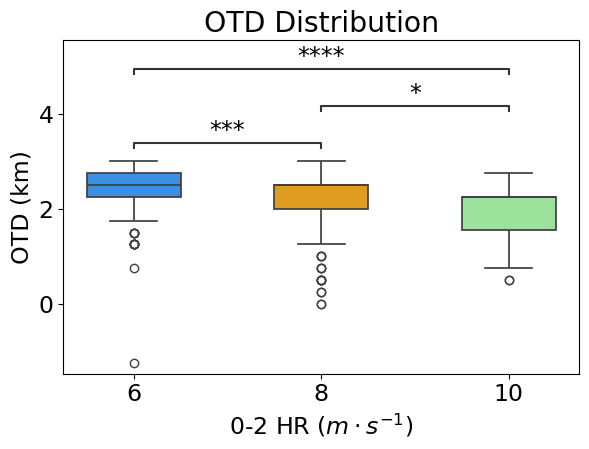

In [11]:
ax = sns.boxplot(ot_df[['6']],  vert= True, color = 'dodgerblue', width = 0.5, linewidth=1.25)
sns.boxplot(ot_df[['8']],  color = 'orange', vert= True, width=0.5, linewidth=1.25)
sns.boxplot(ot_df[['10']], vert=True, color = 'lightgreen', width = 0.5, linewidth=1.25)
plt.title(r'OTD Distribution')
plt.ylabel(r'OTD (km)')
plt.xlabel(r'0-2 HR ($m\cdot s^{-1}$)')
plt.tight_layout()
pairs=[("6", "8"), ("6", "10"), ("8", "10")]
#pairs=[("31", "33"), ("31", "35"), ("33", "35")]
annotator = Annotator(ax, pairs, data=ot_df)
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()
plt.savefig('otd_hr_boxplot.png')

In [145]:
srh_631 = pd.read_csv('/Users/melinda3/Downloads/srh_stats_with_motion631.csv')
srh_633 = pd.read_csv('/Users/melinda3/Downloads/srh_stats_with_motion633.csv') 
srh_635 = pd.read_csv('/Users/melinda3/Downloads/srh_stats_with_motion635.csv')
srh_831 = pd.read_csv('/Users/melinda3/Downloads/srh_stats_with_motion831.csv')
srh_833 = pd.read_csv('/Users/melinda3/Downloads/srh_stats_with_motion833.csv')
srh_835 = pd.read_csv('/Users/melinda3/Downloads/srh_stats_with_motion835.csv')
srh_1031 = pd.read_csv('/Users/melinda3/Downloads/srh_stats_with_motion1031.csv')
srh_1033 = pd.read_csv('/Users/melinda3/Downloads/srh_stats_with_motion1033.csv')
srh_1035 = pd.read_csv('/Users/melinda3/Downloads/srh_stats_with_motion1035.csv')

In [146]:
srh_01_631 = srh_631['Avg01']
srh_03_631 = srh_631['Avg03']
srh_06_631 = srh_631['Avg06']

srh_01_633 = srh_633['Avg01'] 
srh_03_633 = srh_633['Avg03']
srh_06_633 = srh_633['Avg06']

srh_01_635 = srh_635['Avg01']
srh_03_635 = srh_635['Avg03']
srh_06_635 = srh_635['Avg06']

srh_01_831 = srh_831['Avg01']
srh_03_831 = srh_831['Avg03']
srh_06_831 = srh_831['Avg06']

srh_01_833 = srh_833['Avg01'] 
srh_03_833 = srh_833['Avg03']
srh_06_833 = srh_833['Avg06']

srh_01_835 = srh_835['Avg01']
srh_03_835 = srh_835['Avg03']
srh_06_835 = srh_835['Avg06']

srh_01_1031 = srh_1031['Avg01']
srh_03_1031 = srh_1031['Avg03']
srh_06_1031 = srh_1031['Avg06']

srh_01_1033 = srh_1033['Avg01'] 
srh_03_1033 = srh_1033['Avg03']
srh_06_1033 = srh_1033['Avg06']

srh_01_1035 = srh_1035['Avg01']
srh_03_1035 = srh_1035['Avg03']
srh_06_1035 = srh_1035['Avg06']


In [147]:
srh_01_6 = np.append(srh_01_631, srh_01_633)
srh_01_all6 = np.append(srh_01_6, srh_01_635)

srh_01_8 = np.append(srh_01_831, srh_01_833)
srh_01_all8 = np.append(srh_01_8, srh_01_835)

srh_01_10 = np.append(srh_01_1031, srh_01_1033)
srh_01_all10 = np.append(srh_01_10, srh_01_1035)

srh_01_dict = {'6':srh_01_all6, '8':srh_01_all8, '10':srh_01_all10}
#Combine these into a labeled dataframe
srh_01 = pd.DataFrame(dict([ (k,pd.Series(v)) for k,v in srh_01_dict.items() ]))

srh_03_6 = np.append(srh_03_631, srh_03_633)
srh_03_all6 = np.append(srh_03_6, srh_03_635)

srh_03_8 = np.append(srh_03_831, srh_03_833)
srh_03_all8 = np.append(srh_03_8, srh_03_835)

srh_03_10 = np.append(srh_03_1031, srh_03_1033)
srh_03_all10 = np.append(srh_03_10, srh_03_1035)

srh_03_dict = {'6':srh_03_all6, '8':srh_03_all8, '10':srh_03_all10}
#Combine these into a labeled dataframe
srh_03 = pd.DataFrame(dict([ (k,pd.Series(v)) for k,v in srh_03_dict.items() ]))

srh_06_6 = np.append(srh_06_631, srh_06_633)
srh_06_all6 = np.append(srh_06_6, srh_06_635)

srh_06_8 = np.append(srh_06_831, srh_06_833)
srh_06_all8 = np.append(srh_06_8, srh_06_835)

srh_06_10 = np.append(srh_06_1031, srh_06_1033)
srh_06_all10 = np.append(srh_06_10, srh_06_1035)

srh_06_dict = {'6':srh_06_all6, '8':srh_06_all8, '10':srh_06_all10}
#Combine these into a labeled dataframe
srh_06 = pd.DataFrame(dict([ (k,pd.Series(v)) for k,v in srh_06_dict.items() ]))

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

6 vs. 8: Mann-Whitney-Wilcoxon test two-sided, P_val:9.199e-21 U_stat=1.170e+03
8 vs. 10: Mann-Whitney-Wilcoxon test two-sided, P_val:1.874e-08 U_stat=1.457e+03
6 vs. 10: Mann-Whitney-Wilcoxon test two-sided, P_val:3.720e-23 U_stat=2.930e+02


(<Axes: title={'center': '0-3SRH Distribution'}, xlabel='0-2 HR ($m\\cdot s^{-1}$)', ylabel='SRH ($m^{2}\\cdot s^{-2}$)'>,
  <statannotations.Annotation.Annotation at 0x14256d400>])

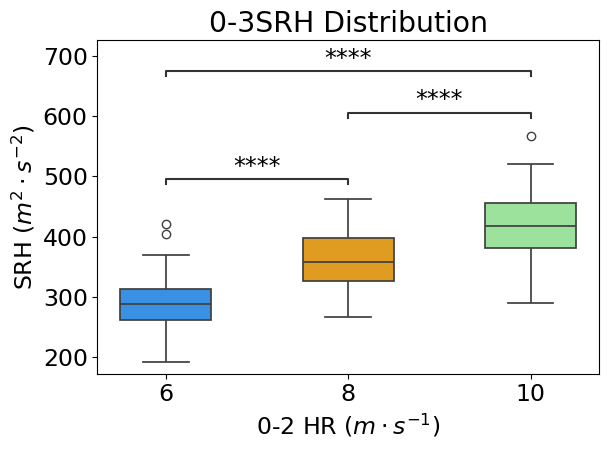

In [148]:
ax = sns.boxplot(srh_03[['6']],  vert= True, color = 'dodgerblue', width = 0.5, linewidth=1.25)
sns.boxplot(srh_03[['8']],  color = 'orange', vert= True, width=0.5, linewidth=1.25)
sns.boxplot(srh_03[['10']], vert=True, color = 'lightgreen', width = 0.5, linewidth=1.25)
plt.title(r'0-3SRH Distribution')
plt.ylabel(r'SRH ($m^{2}\cdot s^{-2}$)')
plt.xlabel(r'0-2 HR ($m\cdot s^{-1}$)')
plt.tight_layout()
pairs=[("6", "8"), ("6", "10"), ("8", "10")]
#pairs=[("31", "33"), ("31", "35"), ("33", "35")]
annotator = Annotator(ax, pairs, data=srh_03)
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()
#plt.savefig('srh_03_hr_boxplot.png')

In [40]:
#Let's load in the bigger dataframes to breakdown those boxplots by height
low_631 = pd.read_csv('/Users/melinda3/Downloads/low_631.csv')
mid_631 = pd.read_csv('/Users/melinda3/Downloads/mid_631.csv')
high_631 = pd.read_csv('/Users/melinda3/Downloads/high_631.csv')

low_633 = pd.read_csv('/Users/melinda3/Downloads/low_633.csv')
mid_633 = pd.read_csv('/Users/melinda3/Downloads/mid_633.csv')
high_633 = pd.read_csv('/Users/melinda3/Downloads/high_633.csv')

low_635 = pd.read_csv('/Users/melinda3/Downloads/low_635.csv')
mid_635 = pd.read_csv('/Users/melinda3/Downloads/mid_635.csv')
high_635 = pd.read_csv('/Users/melinda3/Downloads/high_635.csv')

#Let's load in the bigger dataframes to breakdown those boxplots by height
low_831 = pd.read_csv('/Users/melinda3/Downloads/low_831.csv')
mid_831 = pd.read_csv('/Users/melinda3/Downloads/mid_831.csv')
high_831 = pd.read_csv('/Users/melinda3/Downloads/high_831.csv')

low_833 = pd.read_csv('/Users/melinda3/Downloads/low_833.csv')
mid_833 = pd.read_csv('/Users/melinda3/Downloads/mid_833.csv')
high_833 = pd.read_csv('/Users/melinda3/Downloads/high_833.csv')

low_835 = pd.read_csv('/Users/melinda3/Downloads/low_835.csv')
mid_835 = pd.read_csv('/Users/melinda3/Downloads/mid_835.csv')
high_835 = pd.read_csv('/Users/melinda3/Downloads/high_835.csv')

#Let's load in the bigger dataframes to breakdown those boxplots by height
low_1031 = pd.read_csv('/Users/melinda3/Downloads/low_1031.csv')
mid_1031 = pd.read_csv('/Users/melinda3/Downloads/mid_1031.csv')
high_1031 = pd.read_csv('/Users/melinda3/Downloads/high_1031.csv')

low_1033 = pd.read_csv('/Users/melinda3/Downloads/low_1033.csv')
mid_1033 = pd.read_csv('/Users/melinda3/Downloads/mid_1033.csv')
high_1033 = pd.read_csv('/Users/melinda3/Downloads/high_1033.csv')

low_1035 = pd.read_csv('/Users/melinda3/Downloads/low_1035.csv')
mid_1035 = pd.read_csv('/Users/melinda3/Downloads/mid_1035.csv')
high_1035 = pd.read_csv('/Users/melinda3/Downloads/high_1035.csv')

In [41]:
#Let's make some boxplots with some features of interest
#low_631 = low_631[low_631.time > 87]
grouped_time_631_low = low_631.groupby('time').median()
#mid_631 = mid_631[mid_631.time > 87]
grouped_time_631_mid = mid_631.groupby('time').median()
#high_631 = high_631[high_631.time > 87]
grouped_time_631_high = high_631.groupby('time').median()
#low_633 = low_633[low_633.time > 87]
grouped_time_633_low = low_633.groupby('time').median()
#mid_633 = mid_633[mid_633.time > 87]
grouped_time_633_mid = mid_633.groupby('time').median()
#high_633 = high_633[high_633.time > 87]
grouped_time_633_high = high_633.groupby('time').median()
#low_635 = low_635[low_635.time > 87]
grouped_time_635_low = low_635.groupby('time').median()
#mid_635 = mid_635[mid_635.time > 87]
grouped_time_635_mid = mid_635.groupby('time').median()
#high_635 = high_635[high_635.time > 87]
grouped_time_635_high = high_635.groupby('time').median()

#low_831 = low_831[low_831.time > 87]
grouped_time_831_low = low_831.groupby('time').median()
#mid_831 = mid_831[mid_831.time > 87]
grouped_time_831_mid = mid_831.groupby('time').median()
#high_831 = high_831[high_831.time > 87]
grouped_time_831_high = high_831.groupby('time').median()
#low_833 = low_833[low_833.time > 87]
grouped_time_833_low = low_833.groupby('time').median()
#mid_833 = mid_833[mid_833.time > 87]
grouped_time_833_mid = mid_833.groupby('time').median()
#high_833 = high_833[high_833.time > 87]
grouped_time_833_high = high_833.groupby('time').median()
#low_835 = low_835[low_835.time > 87]
grouped_time_835_low = low_835.groupby('time').median()
#mid_835 = mid_835[mid_835.time > 87]
grouped_time_835_mid = mid_835.groupby('time').median()
#high_835 = high_835[high_835.time > 87]
grouped_time_835_high = high_835.groupby('time').median()

#low_1031 = low_1031[low_1031.time > 87]
grouped_time_1031_low = low_1031.groupby('time').median()
#mid_1031 = mid_1031[mid_1031.time > 87]
grouped_time_1031_mid = mid_1031.groupby('time').median()
#high_1031 = high_1031[high_1031.time > 87]
grouped_time_1031_high = high_1031.groupby('time').median()
#low_1033 = low_1033[low_1033.time > 87]
grouped_time_1033_low = low_1033.groupby('time').median()
#mid_1033 = mid_1033[mid_1033.time > 87]
grouped_time_1033_mid = mid_1033.groupby('time').median()
#high_1033 = high_1033[high_1033.time > 87]
grouped_time_1033_high = high_1033.groupby('time').median()
#low_1035 = low_1035[low_1035.time > 87]
grouped_time_1035_low = low_1035.groupby('time').median()
#mid_1035 = mid_1035[mid_1035.time > 87]
grouped_time_1035_mid = mid_1035.groupby('time').median()
#high_1035 = high_1035[high_1035.time > 87]
grouped_time_1035_high = high_1035.groupby('time').median()

In [52]:
otd_6_low = np.append(grouped_time_631_low['buoyavg_over_polygon'], grouped_time_633_low['buoyavg_over_polygon'])
otd_all6_low = np.append(otd_6_low, grouped_time_635_low['buoyavg_over_polygon'])
otd_6_mid = np.append(grouped_time_631_mid['buoyavg_over_polygon'], grouped_time_633_mid['buoyavg_over_polygon'])
otd_all6_mid = np.append(otd_6_mid, grouped_time_635_mid['buoyavg_over_polygon'])
otd_6_high = np.append(grouped_time_631_high['buoyavg_over_polygon'], grouped_time_633_high['buoyavg_over_polygon'])
otd_all6_high = np.append(otd_6_high, grouped_time_635_high['buoyavg_over_polygon'])

otd_8_low = np.append(grouped_time_831_low['buoyavg_over_polygon'], grouped_time_833_low['buoyavg_over_polygon'])
otd_all8_low = np.append(otd_8_low, grouped_time_835_low['buoyavg_over_polygon'])
otd_8_mid = np.append(grouped_time_831_mid['buoyavg_over_polygon'], grouped_time_833_mid['buoyavg_over_polygon'])
otd_all8_mid = np.append(otd_8_mid, grouped_time_835_mid['buoyavg_over_polygon'])
otd_8_high = np.append(grouped_time_831_high['buoyavg_over_polygon'], grouped_time_833_high['buoyavg_over_polygon'])
otd_all8_high = np.append(otd_8_high, grouped_time_835_high['buoyavg_over_polygon'])

otd_10_low = np.append(grouped_time_1031_low['buoyavg_over_polygon'], grouped_time_1033_low['buoyavg_over_polygon'])
otd_all10_low = np.append(otd_10_low, grouped_time_1035_low['buoyavg_over_polygon'])
otd_10_mid = np.append(grouped_time_1031_mid['buoyavg_over_polygon'], grouped_time_1033_mid['buoyavg_over_polygon'])
otd_all10_mid = np.append(otd_10_mid, grouped_time_1035_mid['buoyavg_over_polygon'])
otd_10_high = np.append(grouped_time_1031_high['buoyavg_over_polygon'], grouped_time_1033_high['buoyavg_over_polygon'])
otd_all10_high = np.append(otd_10_high, grouped_time_1035_high['buoyavg_over_polygon'])


ot_dict = {'6_low':otd_all6_low, '6_mid':otd_all6_mid, '6_high':otd_all6_high, \
            '8_low':otd_all8_low, '8_mid':otd_all8_mid, '8_high':otd_all8_high,\
            '10_low':otd_all10_low, '10_mid':otd_all10_mid, '10_high':otd_all10_high}
#ADD HIGHS BACK IN AFTER GETTING THEM FROM KEELING!!!

#Combine these into a labeled dataframe
ot_df = pd.DataFrame(dict([ (k,pd.Series(v)) for k,v in ot_dict.items() ]))

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

6_high vs. 8_high: Mann-Whitney-Wilcoxon test two-sided, P_val:1.014e-01 U_stat=4.056e+03
8_high vs. 10_high: Mann-Whitney-Wilcoxon test two-sided, P_val:3.368e-01 U_stat=2.576e+03
6_high vs. 10_high: Mann-Whitney-Wilcoxon test two-sided, P_val:2.866e-02 U_stat=2.447e+03


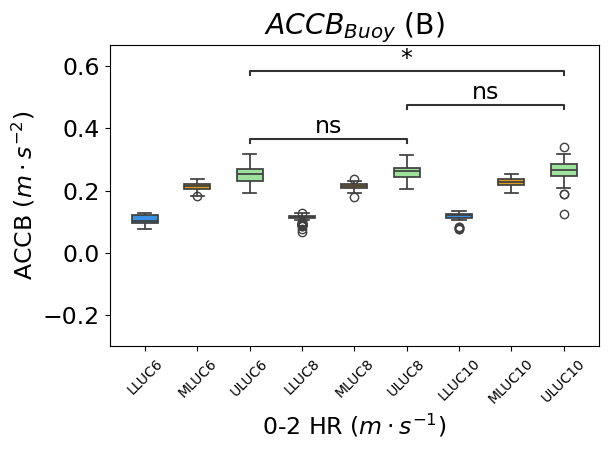

In [54]:
ax = sns.boxplot(ot_df[['6_low']],  vert= True, color = 'dodgerblue', width = 0.5, linewidth=1.25)
sns.boxplot(ot_df[['6_mid']],  color = 'orange', vert= True, width=0.5, linewidth=1.25)
sns.boxplot(ot_df[['6_high']], vert=True, color = 'lightgreen', width = 0.5, linewidth=1.25)
sns.boxplot(ot_df[['8_low']], vert=True, color = 'dodgerblue', width=0.5, linewidth=1.25)
sns.boxplot(ot_df[['8_mid']], color = 'orange', vert = True, width=0.5, linewidth=1.25)
sns.boxplot(ot_df[['8_high']], vert=True, color = 'lightgreen', width = 0.5, linewidth=1.25)
sns.boxplot(ot_df[['10_low']], vert=True, color = 'dodgerblue', width = 0.5, linewidth=1.25)
sns.boxplot(ot_df[['10_mid']], color = 'orange', vert = True, width = 0.5, linewidth=1.25)
sns.boxplot(ot_df[['10_high']], vert=True, color = 'lightgreen', width = 0.5, linewidth=1.25)
#plt.title(r'ACCB ($\mathrm{-(\frac{1}{\overline{\rho}} \frac{\partial p^\prime_{b}}{\partial z} - B))}$')
#plt.title(r'$ACCB_{VPGF}$  $(\mathrm{-(\frac{1}{\overline{\rho}} \frac{\partial p^\prime_{b}}{\partial z}})$')
plt.title(r'$ACCB_{Buoy}$ (B)')
plt.ylabel(r'ACCB ($m\cdot s^{-2}$)')
plt.xlabel(r'0-2 HR ($m\cdot s^{-1}$)')
ax.set_xticks(['6_low', '6_mid', '6_high','8_low', '8_mid', '8_high','10_low', '10_mid', '10_high'],\
              labels = ['LLUC6', 'MLUC6', 'ULUC6', 'LLUC8', 'MLUC8', 'ULUC8','LLUC10', 'MLUC10', 'ULUC10'],\
              fontsize = 10, rotation = 45)
ax.set_ylim(-0.3, 0.3)
plt.tight_layout()
pairs=[("6_high", "8_high"), ("6_high", "10_high"), ("8_high", "10_high")]
#pairs=[("6", "33"), ("31", "35"), ("33", "35")]
annotator = Annotator(ax, pairs, data=ot_df)
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()
plt.savefig('bouy_hr_height_bxplt.png')

In [ ]:
otd_31_low = np.append(grouped_time_631_low['buoyavg_over_polygon'], grouped_time_831_low['buoyavg_over_polygon'])
otd_all31_low = np.append(otd_31_low, grouped_time_1031_low['buoyavg_over_polygon'])
otd_31_mid = np.append(grouped_time_631_mid['buoyavg_over_polygon'], grouped_time_831_mid['buoyavg_over_polygon'])
otd_all31_mid = np.append(otd_31_mid, grouped_time_1031_mid['buoyavg_over_polygon'])
otd_31_high = np.append(grouped_time_631_high['buoyavg_over_polygon'], grouped_time_831_high['buoyavg_over_polygon'])
otd_all31_high = np.append(otd_31_high, grouped_time_1031_high['buoyavg_over_polygon'])

otd_33_low = np.append(grouped_time_633_low['buoyavg_over_polygon'], grouped_time_833_low['buoyavg_over_polygon'])
otd_all33_low = np.append(otd_33_low, grouped_time_1033_low['buoyavg_over_polygon'])
otd_33_mid = np.append(grouped_time_633_mid['buoyavg_over_polygon'], grouped_time_833_mid['buoyavg_over_polygon'])
otd_all33_mid = np.append(otd_33_mid, grouped_time_1033_mid['buoyavg_over_polygon'])
otd_33_high = np.append(grouped_time_633_high['buoyavg_over_polygon'], grouped_time_833_high['buoyavg_over_polygon'])
otd_all33_high = np.append(otd_33_high, grouped_time_1033_high['buoyavg_over_polygon'])

otd_35_low = np.append(grouped_time_635_low['buoyavg_over_polygon'], grouped_time_835_low['buoyavg_over_polygon'])
otd_all35_low = np.append(otd_35_low, grouped_time_1035_low['buoyavg_over_polygon'])
otd_35_mid = np.append(grouped_time_635_mid['buoyavg_over_polygon'], grouped_time_835_mid['buoyavg_over_polygon'])
otd_all35_mid = np.append(otd_35_mid, grouped_time_1035_mid['buoyavg_over_polygon'])
otd_35_high = np.append(grouped_time_635_high['buoyavg_over_polygon'], grouped_time_835_high['buoyavg_over_polygon'])
otd_all35_high = np.append(otd_35_high, grouped_time_1035_high['buoyavg_over_polygon'])


ot_dict = {'31_low':otd_all31_low, '31_mid':otd_all31_mid, '31_high':otd_all31_high, \
            '33_low':otd_all33_low, '33_mid':otd_all33_mid, '33_high':otd_all33_high,\
            '35_low':otd_all35_low, '35_mid':otd_all35_mid, '35_high':otd_all35_high}
#ADD HIGHS BACK IN AFTER GETTING THEM FROM KEELING!!!

#Combine these into a labeled dataframe
ot_df = pd.DataFrame(dict([ (k,pd.Series(v)) for k,v in ot_dict.items() ]))

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

31_high vs. 33_high: Mann-Whitney-Wilcoxon test two-sided, P_val:6.130e-01 U_stat=3.614e+03
33_high vs. 35_high: Mann-Whitney-Wilcoxon test two-sided, P_val:6.577e-01 U_stat=3.747e+03
31_high vs. 35_high: Mann-Whitney-Wilcoxon test two-sided, P_val:9.691e-01 U_stat=3.430e+03


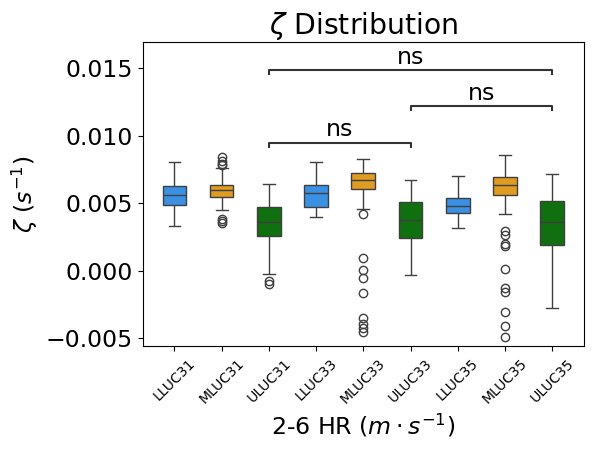

In [ ]:
ax = sns.boxplot(ot_df[['31_low']],  vert= True, color = 'dodgerblue', width = 0.5)
sns.boxplot(ot_df[['31_mid']],  color = 'orange', vert= True, width=0.5)
sns.boxplot(ot_df[['31_high']], vert=True, color = 'green', width = 0.5)
sns.boxplot(ot_df[['33_low']], vert=True, color = 'dodgerblue', width=0.5)
sns.boxplot(ot_df[['33_mid']], color = 'orange', vert = True, width=0.5)
sns.boxplot(ot_df[['33_high']], vert=True, color = 'green', width = 0.5)
sns.boxplot(ot_df[['35_low']], vert=True, color = 'dodgerblue', width = 0.5)
sns.boxplot(ot_df[['35_mid']], color = 'orange', vert = True, width = 0.5)
sns.boxplot(ot_df[['35_high']], vert=True, color = 'green', width = 0.5)
plt.title(r'$\zeta$ Distribution')
plt.ylabel(r'$\zeta$ ($s^{-1}$)')
plt.xlabel(r'2-6 HR ($m\cdot s^{-1}$)')
ax.set_xticks(['31_low', '31_mid', '31_high','33_low', '33_mid', '33_high','35_low', '35_mid', '35_high'],\
              labels = ['LLUC31', 'MLUC31', 'ULUC31', 'LLUC33', 'MLUC33', 'ULUC33','LLUC35', 'MLUC35', 'ULUC35'],\
              fontsize = 10, rotation = 45)
plt.tight_layout()
pairs=[("31_high", "33_high"), ("33_high", "35_high"), ("31_high", "35_high")]
#pairs=[("6", "33"), ("31", "35"), ("33", "35")]
annotator = Annotator(ax, pairs, data=ot_df)
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()
plt.savefig('buoyavg_hl_height_bxplt.png')

In [82]:
#Let's plot the paths of the average location updraft cores over time to see how far they diverge from one another
low_631_pos_x = grouped_time_631_mid['w_loc_x']
low_631_pos_y = grouped_time_631_mid['w_loc_y']
low_633_pos_x = grouped_time_633_mid['w_loc_x']
low_633_pos_y = grouped_time_633_mid['w_loc_y']
low_635_pos_x = grouped_time_635_mid['w_loc_x']
low_635_pos_y = grouped_time_635_mid['w_loc_y']

#Let's plot the paths of the average location updraft cores over time to see how far they diverge from one another
low_831_pos_x = grouped_time_831_mid['w_loc_x']
low_831_pos_y = grouped_time_831_mid['w_loc_y']
low_833_pos_x = grouped_time_833_mid['w_loc_x']
low_833_pos_y = grouped_time_833_mid['w_loc_y']
low_835_pos_x = grouped_time_835_mid['w_loc_x']
low_835_pos_y = grouped_time_835_mid['w_loc_y']
#Let's plot the paths of the average location updraft cores over time to see how far they diverge from one another
low_1031_pos_x = grouped_time_1031_mid['w_loc_x']
low_1031_pos_y = grouped_time_1031_mid['w_loc_y']
low_1033_pos_x = grouped_time_1033_mid['w_loc_x']
low_1033_pos_y = grouped_time_1033_mid['w_loc_y']
low_1035_pos_x = grouped_time_1035_mid['w_loc_x']
low_1035_pos_y = grouped_time_1035_mid['w_loc_y']

Text(0, 0.5, 'Y (grid points)')

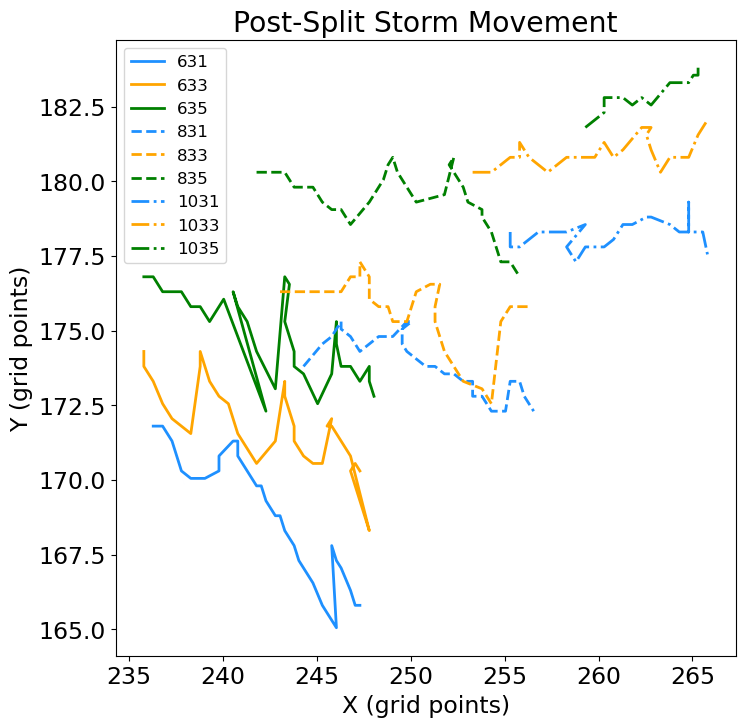

In [87]:
plt.figure(figsize=(8,8))
plt.plot(low_631_pos_x, low_631_pos_y, color = 'dodgerblue', label = '631', lw = 2)
plt.plot(low_633_pos_x, low_633_pos_y, color = 'orange', label = '633', lw = 2)
plt.plot(low_635_pos_x, low_635_pos_y, color = 'green', label = '635', lw = 2)
plt.plot(low_831_pos_x, low_831_pos_y, color = 'dodgerblue', ls = '--', label = '831', lw = 2)
plt.plot(low_833_pos_x, low_833_pos_y, color = 'orange', label = '833', ls = '--', lw = 2)
plt.plot(low_835_pos_x, low_835_pos_y, color = 'green', ls = '--', label = '835', lw = 2)
plt.plot(low_1031_pos_x, low_1031_pos_y, color = 'dodgerblue', ls = '-.', label = '1031', lw = 2)
plt.plot(low_1033_pos_x, low_1033_pos_y, color = 'orange', label = '1033', ls = '-.', lw = 2)
plt.plot(low_1035_pos_x, low_1035_pos_y, color = 'green', ls = '-.', label = '1035', lw = 2)
plt.legend(loc = 'best', fontsize = 12)
plt.title('Post-Split Storm Movement')
plt.xlabel('X (grid points)')
plt.ylabel('Y (grid points)')

In [57]:
tpp_833 = pd.read_csv('/Users/melinda3/Downloads/press_perts_saved_dss_833_all.csv')
tpp_1031 = pd.read_csv('/Users/melinda3/Downloads/press_perts_saved_dss_1031_all.csv')
tpp_631 = pd.read_csv('/Users/melinda3/Downloads/press_perts_saved_dss_631_all.csv')
tpp_1033 = pd.read_csv('/Users/melinda3/Downloads/press_perts_saved_dss_1033_all.csv') 
tpp_633 = pd.read_csv('/Users/melinda3/Downloads/press_perts_saved_dss_633_all.csv')
tpp_635 = pd.read_csv('/Users/melinda3/Downloads/press_perts_saved_dss_635_all.csv')
tpp_1035 = pd.read_csv('/Users/melinda3/Downloads/press_perts_saved_dss_1035_all.csv')
tpp_831 = pd.read_csv('/Users/melinda3/Downloads/press_perts_saved_dss_831_all.csv')
tpp_835 = pd.read_csv('/Users/melinda3/Downloads/press_perts_saved_dss_835_all.csv')


In [58]:
#Repeat the above analysis with UH
#Group the data and prep it for analysis for UH calculations over the various layers
group_631 = tpp_631.groupby('time')
group_633 = tpp_633.groupby('time')
group_635 = tpp_635.groupby('time')
group_831 = tpp_831.groupby('time')
group_833 = tpp_833.groupby('time') 
group_835 = tpp_835.groupby('time')
group_1031 = tpp_1031.groupby('time') 
group_1033 = tpp_1033.groupby('time')
group_1035 = tpp_1035.groupby('time')

In [59]:
uh_245_631 = np.zeros(len(tpp_631['time'].unique()))
uh_245_633 = np.zeros(len(tpp_633['time'].unique()))
uh_245_635 = np.zeros(len(tpp_635['time'].unique()))

uh_245_831 = np.zeros(len(tpp_831['time'].unique()))
uh_245_833 = np.zeros(len(tpp_833['time'].unique()))
uh_245_835 = np.zeros(len(tpp_835['time'].unique()))

uh_245_1031 = np.zeros(len(tpp_1031['time'].unique()))
uh_245_1033 = np.zeros(len(tpp_1033['time'].unique()))
uh_245_1035 = np.zeros(len(tpp_1035['time'].unique()))

uh_48_631 = np.zeros(len(tpp_631['time'].unique()))
uh_48_633 = np.zeros(len(tpp_633['time'].unique()))
uh_48_635 = np.zeros(len(tpp_635['time'].unique()))

uh_48_831 = np.zeros(len(tpp_831['time'].unique()))
uh_48_833 = np.zeros(len(tpp_833['time'].unique()))
uh_48_835 = np.zeros(len(tpp_835['time'].unique()))

uh_48_1031 = np.zeros(len(tpp_1031['time'].unique()))
uh_48_1033 = np.zeros(len(tpp_1033['time'].unique()))
uh_48_1035 = np.zeros(len(tpp_1035['time'].unique()))

uh_8125_631 = np.zeros(len(tpp_631['time'].unique()))
uh_8125_633 = np.zeros(len(tpp_633['time'].unique()))
uh_8125_635 = np.zeros(len(tpp_635['time'].unique()))

uh_8125_831 = np.zeros(len(tpp_831['time'].unique()))
uh_8125_833 = np.zeros(len(tpp_833['time'].unique()))
uh_8125_835 = np.zeros(len(tpp_835['time'].unique()))

uh_8125_1031 = np.zeros(len(tpp_1031['time'].unique()))
uh_8125_1033 = np.zeros(len(tpp_1033['time'].unique()))
uh_8125_1035 = np.zeros(len(tpp_1035['time'].unique()))

uh_25_631 = np.zeros(len(tpp_631['time'].unique()))
uh_25_633 = np.zeros(len(tpp_633['time'].unique()))
uh_25_635 = np.zeros(len(tpp_635['time'].unique()))

uh_25_831 = np.zeros(len(tpp_831['time'].unique()))
uh_25_833 = np.zeros(len(tpp_833['time'].unique()))
uh_25_835 = np.zeros(len(tpp_835['time'].unique()))

uh_25_1031 = np.zeros(len(tpp_1031['time'].unique()))
uh_25_1033 = np.zeros(len(tpp_1033['time'].unique()))
uh_25_1035 = np.zeros(len(tpp_1035['time'].unique()))

In [65]:
def determining_uh(in_group):
    low_out = np.zeros(in_group.ngroups)
    med_out = np.zeros(in_group.ngroups)
    high_out = np.zeros(in_group.ngroups)
    uh_25_out = np.zeros(in_group.ngroups)
    n = 0
    for name, group in in_group:
        current_group = group
        current_low = current_group[(current_group.hght >= 2) & (current_group.hght < 4.5)]
        current_med = current_group[(current_group.hght >=4) & (current_group.hght < 8)] 
        current_high = current_group[(current_group.hght >=8) & (current_group.hght < 12.5)]
        current_25 = current_group[(current_group.hght >= 2) & (current_group.hght < 5)]

        #Get UH for each of the current layers for each time step
        low_uh = sum(current_low['wtzeta'] * 250)
        med_uh = sum(current_med['wtzeta'] * 250)
        high_uh = sum(current_high['wtzeta'] * 250)
        uh_25 = sum(current_25['wtzeta']*250)
        low_out[n] = low_uh
        med_out[n] = med_uh
        high_out[n] = high_uh
        uh_25_out[n] = uh_25
        n+=1

    return low_out, med_out, high_out


In [66]:
uh_245_631, uh_48_631, uh_8125_631 = determining_uh(group_631)
uh_245_633, uh_48_633, uh_8125_633 = determining_uh(group_633)
uh_245_635, uh_48_635, uh_8125_635 = determining_uh(group_635)

uh_245_831, uh_48_831, uh_8125_831 = determining_uh(group_831)
uh_245_833, uh_48_833, uh_8125_833 = determining_uh(group_833)
uh_245_835, uh_48_835, uh_8125_835 = determining_uh(group_835)

uh_245_1031, uh_48_1031, uh_8125_1031 = determining_uh(group_1031)
uh_245_1033, uh_48_1033, uh_8125_1033 = determining_uh(group_1033)
uh_245_1035, uh_48_1035, uh_8125_1035 = determining_uh(group_1035)



In [67]:
uh_6_low = np.append(uh_245_631, uh_245_633)
uh_all6_low = np.append(uh_6_low, uh_245_635)
uh_6_mid = np.append(uh_48_631, uh_48_633)
uh_all6_mid = np.append(uh_6_mid, uh_48_635)
uh_6_high = np.append(uh_8125_631, uh_8125_633)
uh_all6_high = np.append(uh_6_high, uh_8125_635)

uh_8_low = np.append(uh_245_831, uh_245_833)
uh_all8_low = np.append(uh_8_low, uh_245_835)
uh_8_mid = np.append(uh_48_831, uh_48_833)
uh_all8_mid = np.append(uh_8_mid, uh_48_835)
uh_8_high = np.append(uh_8125_831, uh_8125_833)
uh_all8_high = np.append(uh_8_high, uh_8125_835)

uh_10_low = np.append(uh_245_1031, uh_245_1033)
uh_all10_low = np.append(uh_10_low, uh_245_1035)
uh_10_mid = np.append(uh_48_1031, uh_48_1033)
uh_all10_mid = np.append(uh_10_mid, uh_48_1035)
uh_10_high = np.append(uh_8125_1031, uh_8125_1033)
uh_all10_high = np.append(uh_10_high, uh_8125_1035)


uh_dict = {'6_low':uh_all6_low, '6_mid':uh_all6_mid, '6_high':uh_all6_high, \
            '8_low':uh_all8_low, '8_mid':uh_all8_mid, '8_high':uh_all8_high,\
            '10_low':uh_all10_low, '10_mid':uh_all10_mid, '10_high':uh_all10_high}
#ADD HIGHS BACK IN AFTER GETTING THEM FROM KEELING!!!

#Combine these into a labeled dataframe
uh_df = pd.DataFrame(dict([ (k,pd.Series(v)) for k,v in uh_dict.items() ]))

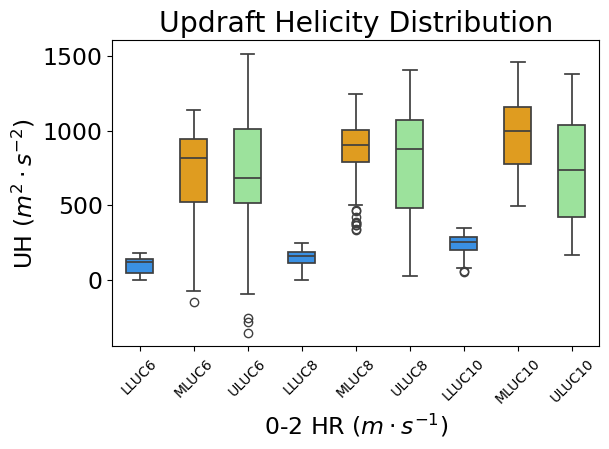

In [70]:
ax = sns.boxplot(uh_df[['6_low']],  vert= True, color = 'dodgerblue', width = 0.5, linewidth=1.25)
sns.boxplot(uh_df[['6_mid']],  color = 'orange', vert= True, width=0.5, linewidth=1.25)
sns.boxplot(uh_df[['6_high']], vert=True, color = 'lightgreen', width = 0.5, linewidth=1.25)
sns.boxplot(uh_df[['8_low']], vert=True, color = 'dodgerblue', width=0.5, linewidth=1.25)
sns.boxplot(uh_df[['8_mid']], color = 'orange', vert = True, width=0.5, linewidth=1.25)
sns.boxplot(uh_df[['8_high']], vert=True, color = 'lightgreen', width = 0.5, linewidth=1.25)
sns.boxplot(uh_df[['10_low']], vert=True, color = 'dodgerblue', width = 0.5, linewidth=1.25)
sns.boxplot(uh_df[['10_mid']], color = 'orange', vert = True, width = 0.5, linewidth=1.25)
sns.boxplot(uh_df[['10_high']], vert=True, color = 'lightgreen', width = 0.5, linewidth=1.25)
plt.title(r'Updraft Helicity Distribution')
plt.ylabel(r'UH ($m^{2}\cdot s^{-2}$)')
plt.xlabel(r'0-2 HR ($m\cdot s^{-1}$)')
ax.set_xticks(['6_low', '6_mid', '6_high','8_low', '8_mid', '8_high','10_low', '10_mid', '10_high'],\
              labels = ['LLUC6', 'MLUC6', 'ULUC6', 'LLUC8', 'MLUC8', 'ULUC8','LLUC10', 'MLUC10', 'ULUC10'],\
              fontsize = 10, rotation = 45)
#ax.set_ylim(-0.22, 0.3)
plt.tight_layout()
pairs=[("6_high", "8_high"), ("6_high", "10_high"), ("8_high", "10_high")]
#pairs=[("6", "33"), ("31", "35"), ("33", "35")]
annuhator = Annotator(ax, pairs, data=uh_df)
annuhator.configure(test='Mann-Whitney', text_format='star', loc='inside')
#annuhator.apply_and_annotate()
plt.savefig('uh_hr_height_bxplt.png')

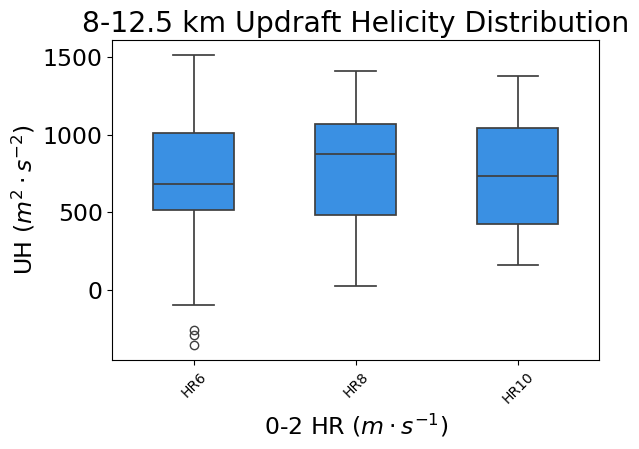

In [37]:
ax = sns.boxplot(uh_df[['6_low']],  vert= True, color = 'dodgerblue', width = 0.5, linewidth=1.25)
#sns.boxplot(uh_df[['6_mid']],  color = 'orange', vert= True, width=0.5, linewidth=1.25)
#sns.boxplot(uh_df[['6_high']], vert=True, color = 'lightgreen', width = 0.5, linewidth=1.25)
sns.boxplot(uh_df[['8_low']], vert=True, color = 'dodgerblue', width=0.5, linewidth=1.25)
#sns.boxplot(uh_df[['8_mid']], color = 'orange', vert = True, width=0.5, linewidth=1.25)
#sns.boxplot(uh_df[['8_high']], vert=True, color = 'lightgreen', width = 0.5, linewidth=1.25)
sns.boxplot(uh_df[['10_low']], vert=True, color = 'dodgerblue', width = 0.5, linewidth=1.25)
#sns.boxplot(uh_df[['10_mid']], color = 'orange', vert = True, width = 0.5, linewidth=1.25)
#sns.boxplot(uh_df[['10_high']], vert=True, color = 'lightgreen', width = 0.5, linewidth=1.25)
plt.title(r'8-12.5 km Updraft Helicity Distribution')
plt.ylabel(r'UH ($m^{2}\cdot s^{-2}$)')
plt.xlabel(r'0-2 HR ($m\cdot s^{-1}$)')
ax.set_xticks(['6_low', '8_low','10_low'],\
              labels = ['HR6', 'HR8', 'HR10'],\
              fontsize = 10, rotation = 45)
#ax.set_ylim(-0.22, 0.3)
plt.tight_layout()
pairs=[("6_low", "8_low"), ("6_low", "10_low"), ("8_low", "10_low")]
#pairs=[("6", "33"), ("31", "35"), ("33", "35")]
annuhator = Annotator(ax, pairs, data=uh_df)
annuhator.configure(test='Mann-Whitney', text_format='star', loc='inside')
#annuhator.apply_and_annotate()
plt.savefig('812uh_hr_height_bxplt.png')